In [97]:
import json
import os

import pandas as pd

# Plot the accuracy

dir = '../data/results/experiments/frequency_experiment_21'

data_df = pd.read_csv(os.path.join(dir, 'data.csv')).drop(columns=['Unnamed: 0'])

with open(os.path.join(dir, 'config.json')) as f:
    config = json.load(f)

config

data_df.groupby(['operator', 'frequency'])['num_tps'].mean()

operator  frequency
1         0            2499.95
          3731         2499.95
10        0            2535.50
          780          1027.50
          2160         2518.75
          3649         2535.10
50        0            2536.25
          763          2536.00
          3624         2535.35
88        0            2535.85
          1844         2525.10
          2675          583.00
          3570         2535.50
Name: num_tps, dtype: float64

In [98]:
from scripts.utils import get_config

data_df['operator'] = data_df['operator'].astype('int')
data_df['complexity'] = data_df['complexity'].astype('int')
data_df['frequency'] = data_df['frequency'].astype('int')
data_df

freq_map = get_config("frequency_map.json")
band_map = get_config("band_map.json")
b_map = {}
for k, v in band_map.items():
    b_map = {**b_map, **v}
fr_map = {}
for k, v in freq_map.items():
    for nr, fr in v.items():
        fr_map[fr] = b_map[nr]

fr_map

data_df['band'] = data_df['frequency'].apply(lambda x: fr_map[x] if x != 0 else 'All')

unique_bands = data_df['band'].unique().tolist()
if 'All' in unique_bands:
    unique_bands.remove('All')
desired_order = sorted(unique_bands) + ['All']

# Convert the column to categorical with the custom order
data_df['band'] = pd.Categorical(data_df['band'], categories=desired_order, ordered=True)
data_df['band'] = data_df['band'].apply(lambda x: f'n{x}' if x != 'All' else x)

/var/folders/sz/wsd2tvj51v1c7jpt5gscdckc0000gn/T/ipykernel_19230/1680101593.py:57: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bands_with_data = df[df['band'].isin(available_bands)].groupby('band').size()
/var/folders/sz/wsd2tvj51v1c7jpt5gscdckc0000gn/T/ipykernel_19230/1680101593.py:64: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_df['band'] = pd.Categorical(plot_df['band'], categories=bands_with_data, ordered=True)


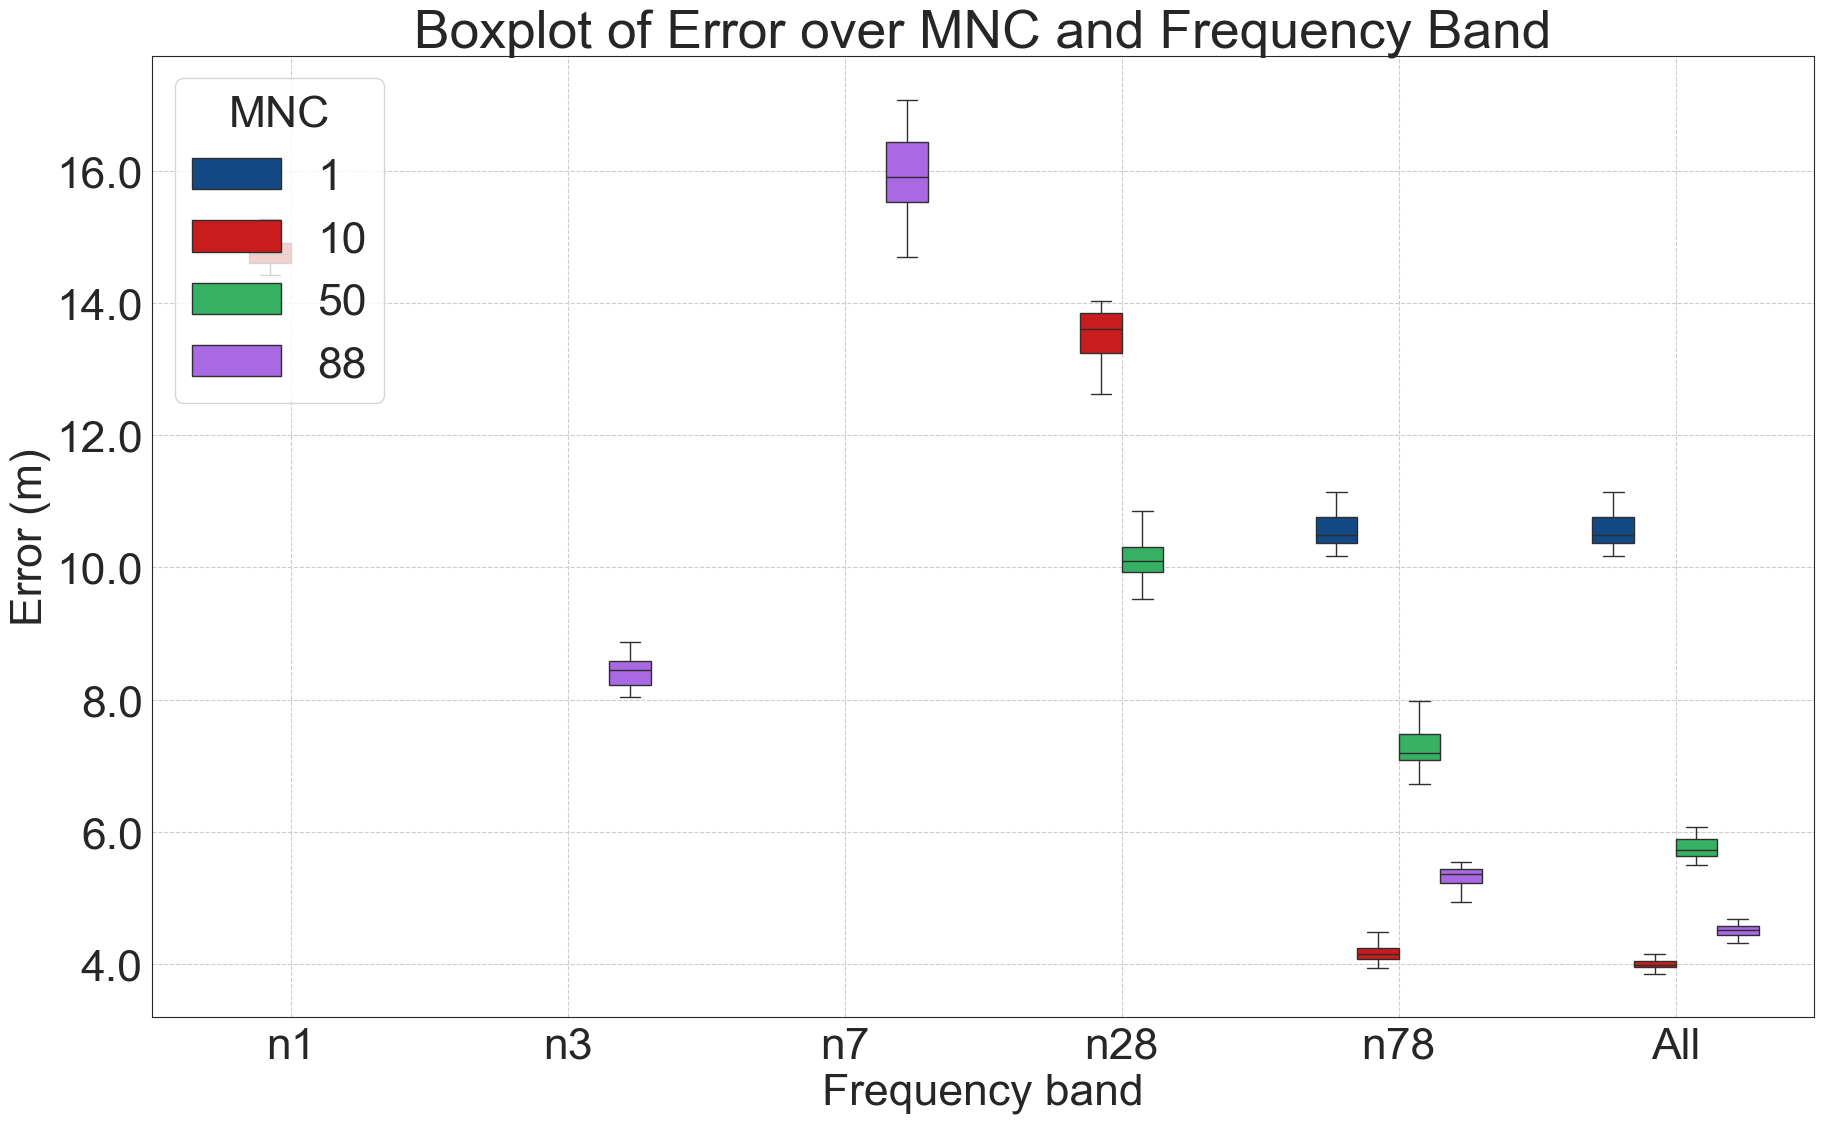

In [105]:

from matplotlib.ticker import FuncFormatter, FormatStrFormatter
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({"font.size": 32})


def make_barplot(df: pd.DataFrame, x_label: str, y_label: str, x: str, y: str, title: str, color: str, hue: str):
    # Set the style to white background
    plt.figure(figsize=(17, 12))
    sns.set_style("white")

    colors = get_config('color_map.json', 'operatorId')
    palette = [v for k, v in colors.items()]

    # Create the boxplot using seaborn
    ax = sns.barplot(x=x, y=y, hue=hue, data=df, width=0.6, palette=palette)

    # Add labels and title
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    plt.legend(title='MNC', loc='upper left')

    # Remove grid or make it very subtle
    plt.grid(linestyle='--')

    from matplotlib.ticker import FormatStrFormatter

    def thousands_formatter(x, pos):
        return f'{x / 1000:,.0f}'.replace(',', ' ').replace('.', ',')

    if y == 'complexity':
        plt.gca().yaxis.set_major_formatter(FuncFormatter(thousands_formatter))
    elif y == 'runtime':
        plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
    else:
        plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

    for container in ax.containers:
        labels = []
        for v in container.datavalues:
            labels.append(f'{v:.1f}'.replace(',', ' ').replace('.', ','))

        ax.bar_label(container, labels=labels, fontsize=22, padding=8)

    # Show the plot
    plt.tight_layout()
    plt.show()


def make_boxplot(df: pd.DataFrame, x_label: str, y_label: str, x: str, y: str, title: str, color: str, hue: str):
    bands_of_interest = ['All', 'n78']
    # Filter to only include bands that have data
    available_bands = [band for band in bands_of_interest if band in df['band'].unique()]

    bands_with_data = df[df['band'].isin(available_bands)].groupby('band').size()
    bands_with_data = bands_with_data[bands_with_data > 0].index.tolist()

    # Create a new dataframe with only the bands that have data
    plot_df = df[df['band'].isin(bands_with_data)]

    # Create a new categorical type with only the categories that have data
    plot_df['band'] = pd.Categorical(plot_df['band'], categories=bands_with_data, ordered=True)
    plot_df = plot_df[plot_df['operator'] != 1]

    # Set the style to white background
    plt.figure(figsize=(19, 12))
    sns.set_style("white")

    colors = get_config('color_map.json', 'operatorId')
    palette = [v for k, v in colors.items()]

    # Determine the hue order to ensure consistent coloring
    hue_order = df[hue].unique()

    # Create the main boxplot using seaborn
    ax_main = sns.boxplot(x=x, y=y, hue=hue, data=df, width=0.6, palette=palette, hue_order=hue_order, showfliers=False)

    # Add labels and title
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    plt.legend(title='MNC', loc='upper left')

    # Remove grid or make it very subtle
    plt.grid(linestyle='--')

    def thousands_formatter(x, pos):
        return f'{x / 1000:,.0f}K'.replace(',', ' ').replace('.', ',')

    if y == 'complexity':
        plt.gca().yaxis.set_major_formatter(FuncFormatter(thousands_formatter))
    elif y == 'runtime':
        plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
    else:
        plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

    # Show the plot
    plt.tight_layout()
    plt.show()


make_boxplot(
    df=data_df,
    x='band',
    y='error',
    hue='operator',
    x_label='Frequency band',
    y_label='Error (m)',
    title='Boxplot of Error over MNC and Frequency Band',
    color='forestgreen'
)

/var/folders/sz/wsd2tvj51v1c7jpt5gscdckc0000gn/T/ipykernel_19230/3993369161.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bands_with_data = data_df[data_df['band'].isin(available_bands)].groupby('band').size()
/var/folders/sz/wsd2tvj51v1c7jpt5gscdckc0000gn/T/ipykernel_19230/3993369161.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_df['band'] = pd.Categorical(plot_df['band'], categories=bands_with_data, ordered=True)


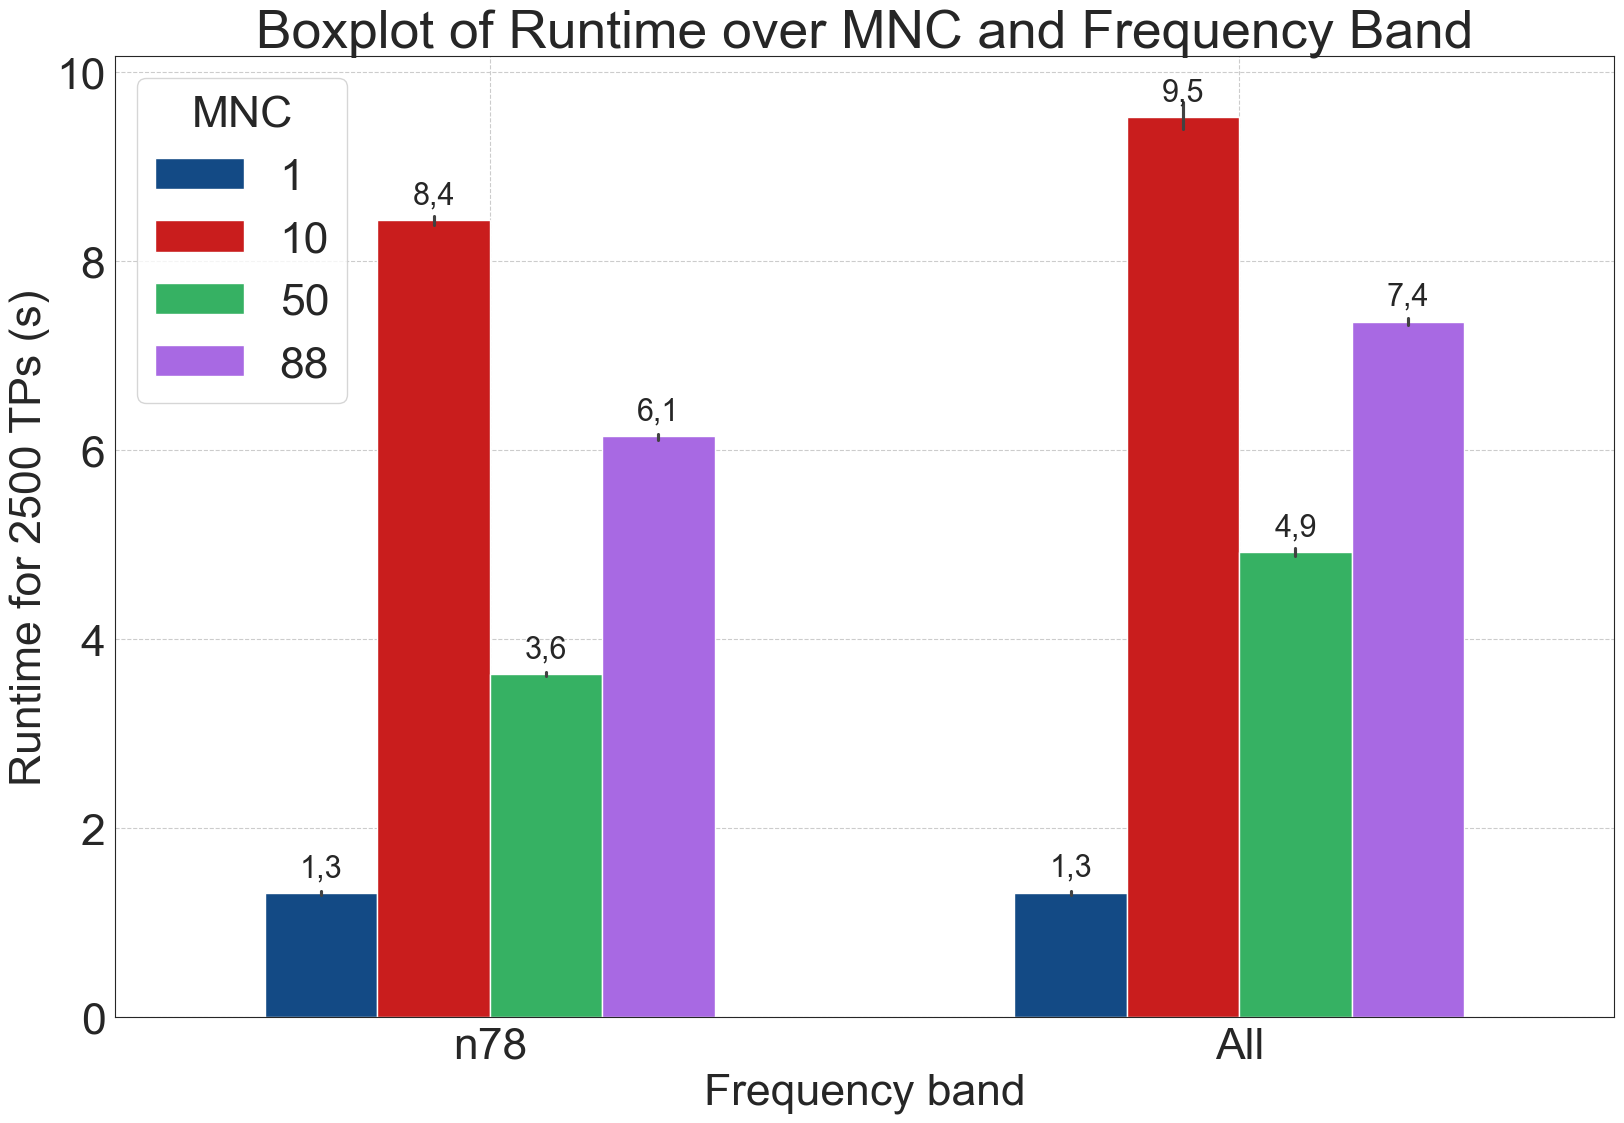

In [109]:
bands_of_interest = ['All', 'n78']
# Filter to only include bands that have data
available_bands = [band for band in bands_of_interest if band in data_df['band'].unique()]

bands_with_data = data_df[data_df['band'].isin(available_bands)].groupby('band').size()
bands_with_data = bands_with_data[bands_with_data > 0].index.tolist()

# Create a new dataframe with only the bands that have data
plot_df = data_df[data_df['band'].isin(bands_with_data)]

# Create a new categorical type with only the categories that have data
plot_df['band'] = pd.Categorical(plot_df['band'], categories=bands_with_data, ordered=True)

# Now plot with the filtered dataframe
# make_boxplot(
#     df=plot_df,
#     x='band',
#     y='error',
#     hue='operator',
#     x_label='Frequency band',
#     y_label='Error (m)',
#     title='Boxplot of Error over MNC and Frequency Band',
#     color='forestgreen'
# )
make_barplot(
    df=plot_df,
    x='band',
    y='runtime',
    hue='operator',
    x_label='Frequency band',
    y_label='Runtime for 2500 TPs (s)',
    title='Boxplot of Runtime over MNC and Frequency Band',
    color='forestgreen'
)


In [96]:
data_df['frequency'] = data_df['frequency'].astype('int')
data_df['runtime'] = data_df['runtime'].astype('int')

data_df.groupby(['operator', 'band'])[['error', 'runtime']].mean().round(1)

baseline = {
    1: 24066.061810,
    10: 224748.709154,
    50: 163386.438246,
    88: 177949.156793
}
for name, group in data_df.groupby('operator'):
    vals = group.groupby('frequency')['runtime'].mean()
    all = vals.iloc[0]
    highest = vals.iloc[-1]

    change = (all - highest) / highest * 100
    print(f'{name}\n\truntime: {change:.2f}%')

    vals = group.groupby('frequency')['error'].mean()
    all = vals.iloc[0]
    highest = vals.iloc[-1]

    change = (highest - all) / highest * 100
    print(f'\terror: {change:.2f}%')





1
	runtime: 15.91%
	error: 0.00%
10
	runtime: 15.29%
	error: 4.17%
50
	runtime: 16.57%
	error: 20.76%
88
	runtime: 26.96%
	error: 15.23%


/var/folders/sz/wsd2tvj51v1c7jpt5gscdckc0000gn/T/ipykernel_19230/4243501565.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_df.groupby(['operator', 'band'])[['error', 'runtime']].mean().round(1)


In [69]:
data_df[data_df['operator'] == 10].groupby('band')['error'].mean()

/var/folders/sz/wsd2tvj51v1c7jpt5gscdckc0000gn/T/ipykernel_96078/3222882128.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_df[data_df['operator'] == 10].groupby('band')['error'].mean()


band
All     4.252329
n3           NaN
n28    52.713336
n66    28.790866
n78     4.510899
n90          NaN
Name: error, dtype: float64

In [43]:
from scripts.utils import *

config = get_config("frequency_map.json")

config

for k, v in config.items():
    print(k)
    print(v.values())


1
dict_values([3731])
10
dict_values([2160, 3649, 3649, 2160, 2160, 780])
50
dict_values([763, 763, 3624, 3624])
88
dict_values([1844, 3570, 3570, 2675])


In [31]:

import matplotlib.patches as mpatches
from scripts.plotting import *


def make_boxplot(
        df: pd.DataFrame,
        title: str,
        x_label: str,
        y_label: str,
        color: Union[str, dict] = "forestgreen",
        baseline: float = None,
        annotate: bool = False,
):
    """
    Creates a boxplot of the given dataframe.

    :param baseline:
    :param df:
    :param title:
    :param x_label:
    :param y_label:
    :param color: Color of the boxes
    """
    data_values = [df[col] for col in df.columns]
    means = [df[col].mean() for col in df.columns]
    num_boxes = len(df.columns)

    plt.figure(figsize=(20, 14))
    median_props = dict(color="black", linewidth="3")
    plot = plt.boxplot(
        data_values,
        patch_artist=True,
        tick_labels=df.columns,
        medianprops=median_props,
    )

    # Handle color assignment
    if isinstance(color, dict):
        for patch, col_name in zip(plot["boxes"], df.columns):
            patch.set_facecolor(color.get(col_name.strip('*'), "forestgreen"))
    else:
        for patch in plot["boxes"]:
            patch.set_facecolor(color)

    for patch, col_name in zip(plot["boxes"], df.columns):
        if col_name[-1] == '*':
            patch.set_hatch('o')
        else:
            patch.set_hatch('/')

    legend_elements = []

    # Add boxes to legend
    for col_name in df.columns:
        hatch = 'o' if col_name[-1] == '*' else '/'
        box_color = color.get(col_name.strip('*'), "forestgreen") if isinstance(color, dict) else color

        label = f'{col_name[:-1]} MHz (best beam)' if col_name[-1] == '*' else f'{col_name} MHz'
        label = f'All frequencies {label.split("all MHz")[1]}' if label.startswith('all MHz') else label
        patch = mpatches.Patch(
            facecolor=box_color,
            hatch=hatch,
            label=label
        )
        legend_elements.append(patch)

    if baseline:
        plt.axhline(
            y=baseline,
            color="red",
            linestyle="-",
            linewidth=2,
            label="Baseline",
        )
        plt.legend(loc="upper right")

    if annotate:
        text_offset = 0.4 if num_boxes < 4 else 0.5

        for i, mean in enumerate(means, 1):
            plt.text(
                i + text_offset,
                mean,
                f"\n{mean:.2f}",
                horizontalalignment="right",
                verticalalignment="center",
                color="black",
            )

    # formatting the plot
    plt.title(title)
    plt.grid(axis="y")
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.legend(handles=legend_elements, loc='upper right')
    plt.margins(y=0.2)

    # Show the plot
    plt.show()




In [32]:

from matplotlib.lines import Line2D


def make_barplot(
        df: pd.DataFrame,
        title: str,
        x_label: str,
        y_label: str,
        color: Union[str, dict] = "skyblue",
        baseline: float = None,
        annotate: bool = False,
):
    """
    Creates a bar plot of the given dataframe.
    """
    if df.empty:
        raise ValueError("The DataFrame is empty.")

    means = df.mean()

    plt.figure(figsize=(20, 12))

    # Handle color assignment
    if isinstance(color, dict):
        colors = [color.get(col.strip('*'), "forestgreen") for col in means.index]
        hatches = ['o' if col[-1] == '*' else '/' for col in means.index]
        bars = plt.bar(
            range(len(means)), means.values, color=colors, tick_label=means.index, hatch=hatches,
        )
    else:
        bars = plt.bar(
            range(len(means)), means.values, color=color, tick_label=means.index
        )

    # Create legend elements
    legend_elements = []

    # Add bars to legend
    for col_name in means.index:
        bar_color = color.get(col_name.strip('*'), "forestgreen") if isinstance(color, dict) else color
        hatch = 'o' if col_name[-1] == '*' else '/'
        label = f'{col_name[:-1]} MHz (best beam)' if col_name[-1] == '*' else f'{col_name} MHz'
        label = f'All frequencies {label.split("all MHz")[1]}' if label.startswith('all MHz') else label

        patch = mpatches.Patch(
            facecolor=bar_color,
            label=label,
            hatch=hatch,
        )
        legend_elements.append(patch)

    # Add baseline to legend if it exists
    if baseline is not None:
        legend_elements.append(Line2D([0], [0], color='red', linestyle='-', linewidth=2, label='Baseline'))

    # Add the legend
    plt.legend(handles=legend_elements, loc='upper left', ncol=2)

    if annotate:
        for i, bar in enumerate(bars):
            height = bar.get_height()
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                height,
                f"{height:.0f}",
                ha="center",
                va="bottom",
            )

    # Formatting the plot
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)

    def thousands_formatter(x, pos):
        return f"{x / 1000:.0f}k"

    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(thousands_formatter))
    plt.tight_layout()
    plt.grid(axis="y")
    plt.margins(y=0.8)
    plt.yscale('log')

    # Show the plot
    plt.show()


Index(['2160', '3649', '780', 'all', '3731', 'all'], dtype='object')


ValueError: X must have 2 or fewer dimensions

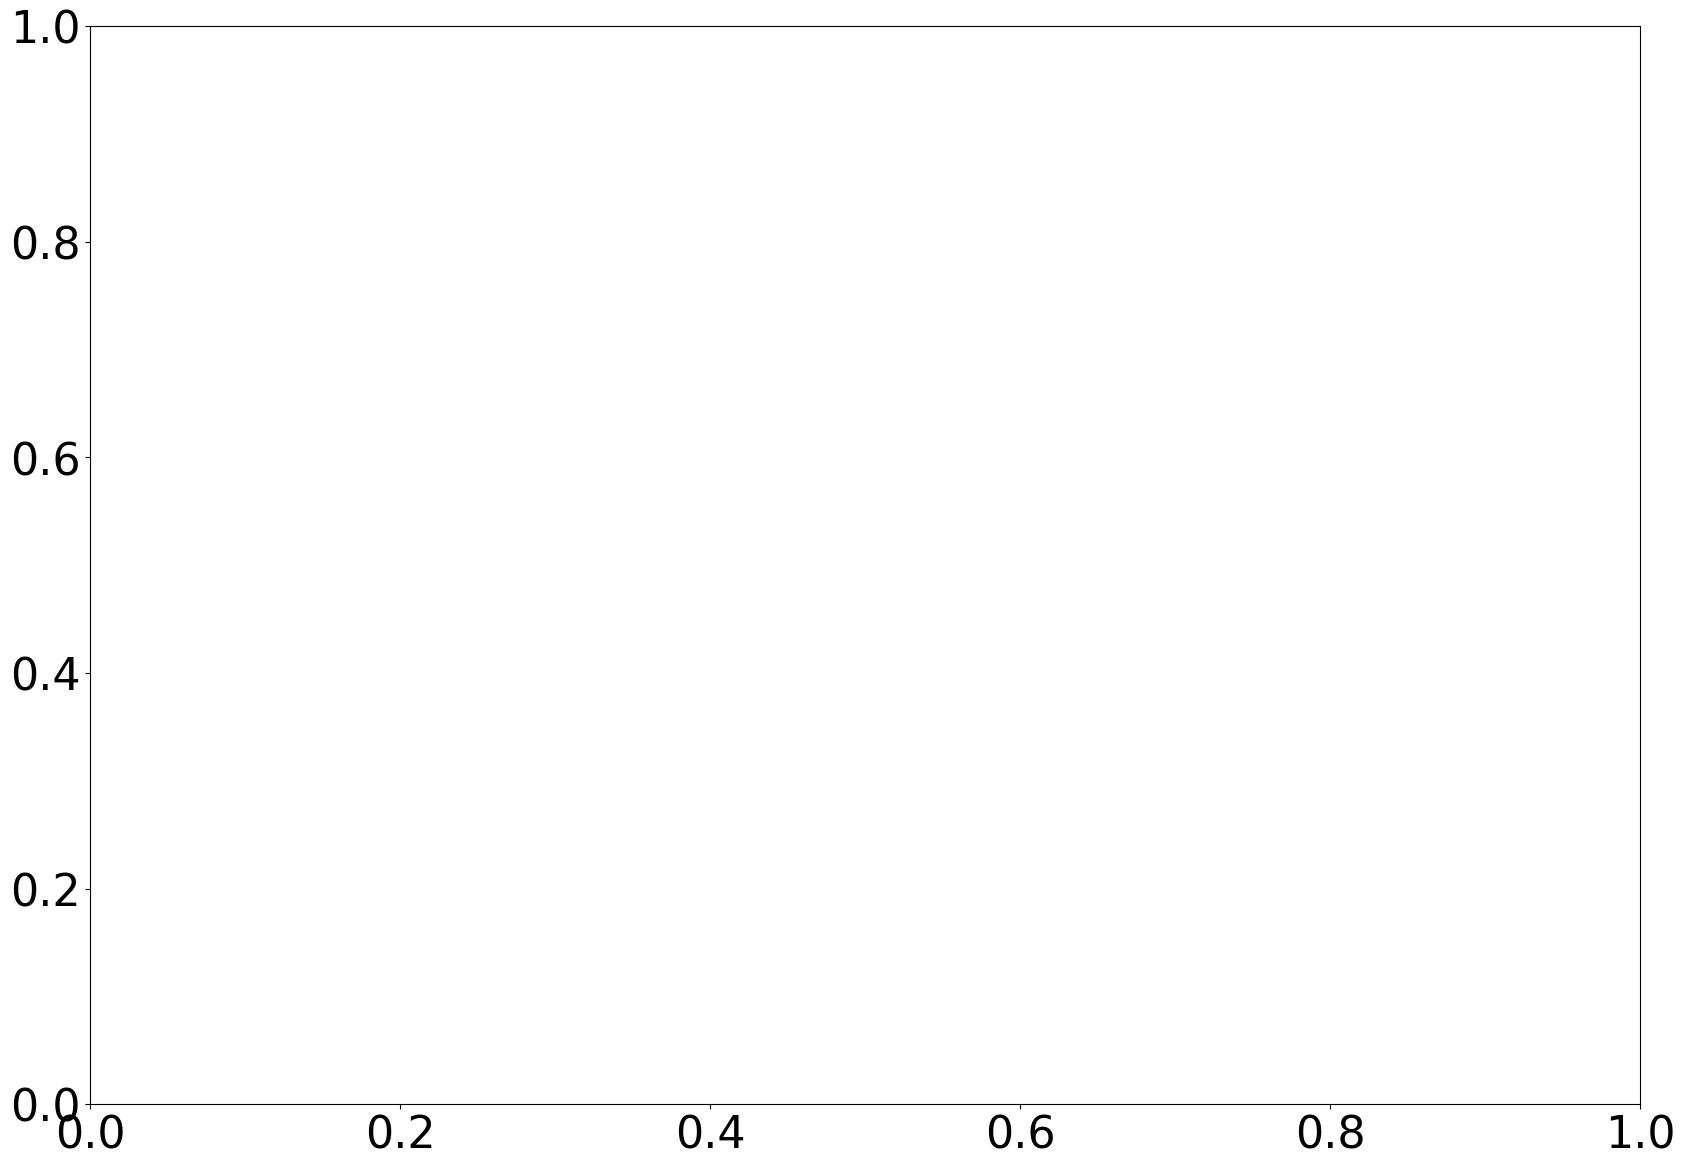

In [42]:
color_map = get_config("color_map.json", "frequency")

column_orders = [
    ['780', '2160', '3649', '3731', 'all'],
]

star_order = list(map(lambda x: x + "*", order))
all_cols = ['780*', '2160', '3649', '3731', 'all']

all_errors = pd.concat([errors_df, errors_df_tim], axis=1)
all_entries = pd.concat([entries_df, entries_df_tim], axis=1)

print(all_errors.columns)
#
make_boxplot(
    df=all_errors,
    title=f'Min average error: {title_string}',
    x_label='Frequency (MHz)',
    y_label='Error (m)',
    color=color_map,
    annotate=True,
)

# make_barplot(
#     df=all_entries,
#     title=f'Number of data points: {title_string}',
#     x_label='Frequency (MHz)',
#     y_label='Number of entries (log)',
#     color=color_map,
#     annotate=True,
# )

all_entries

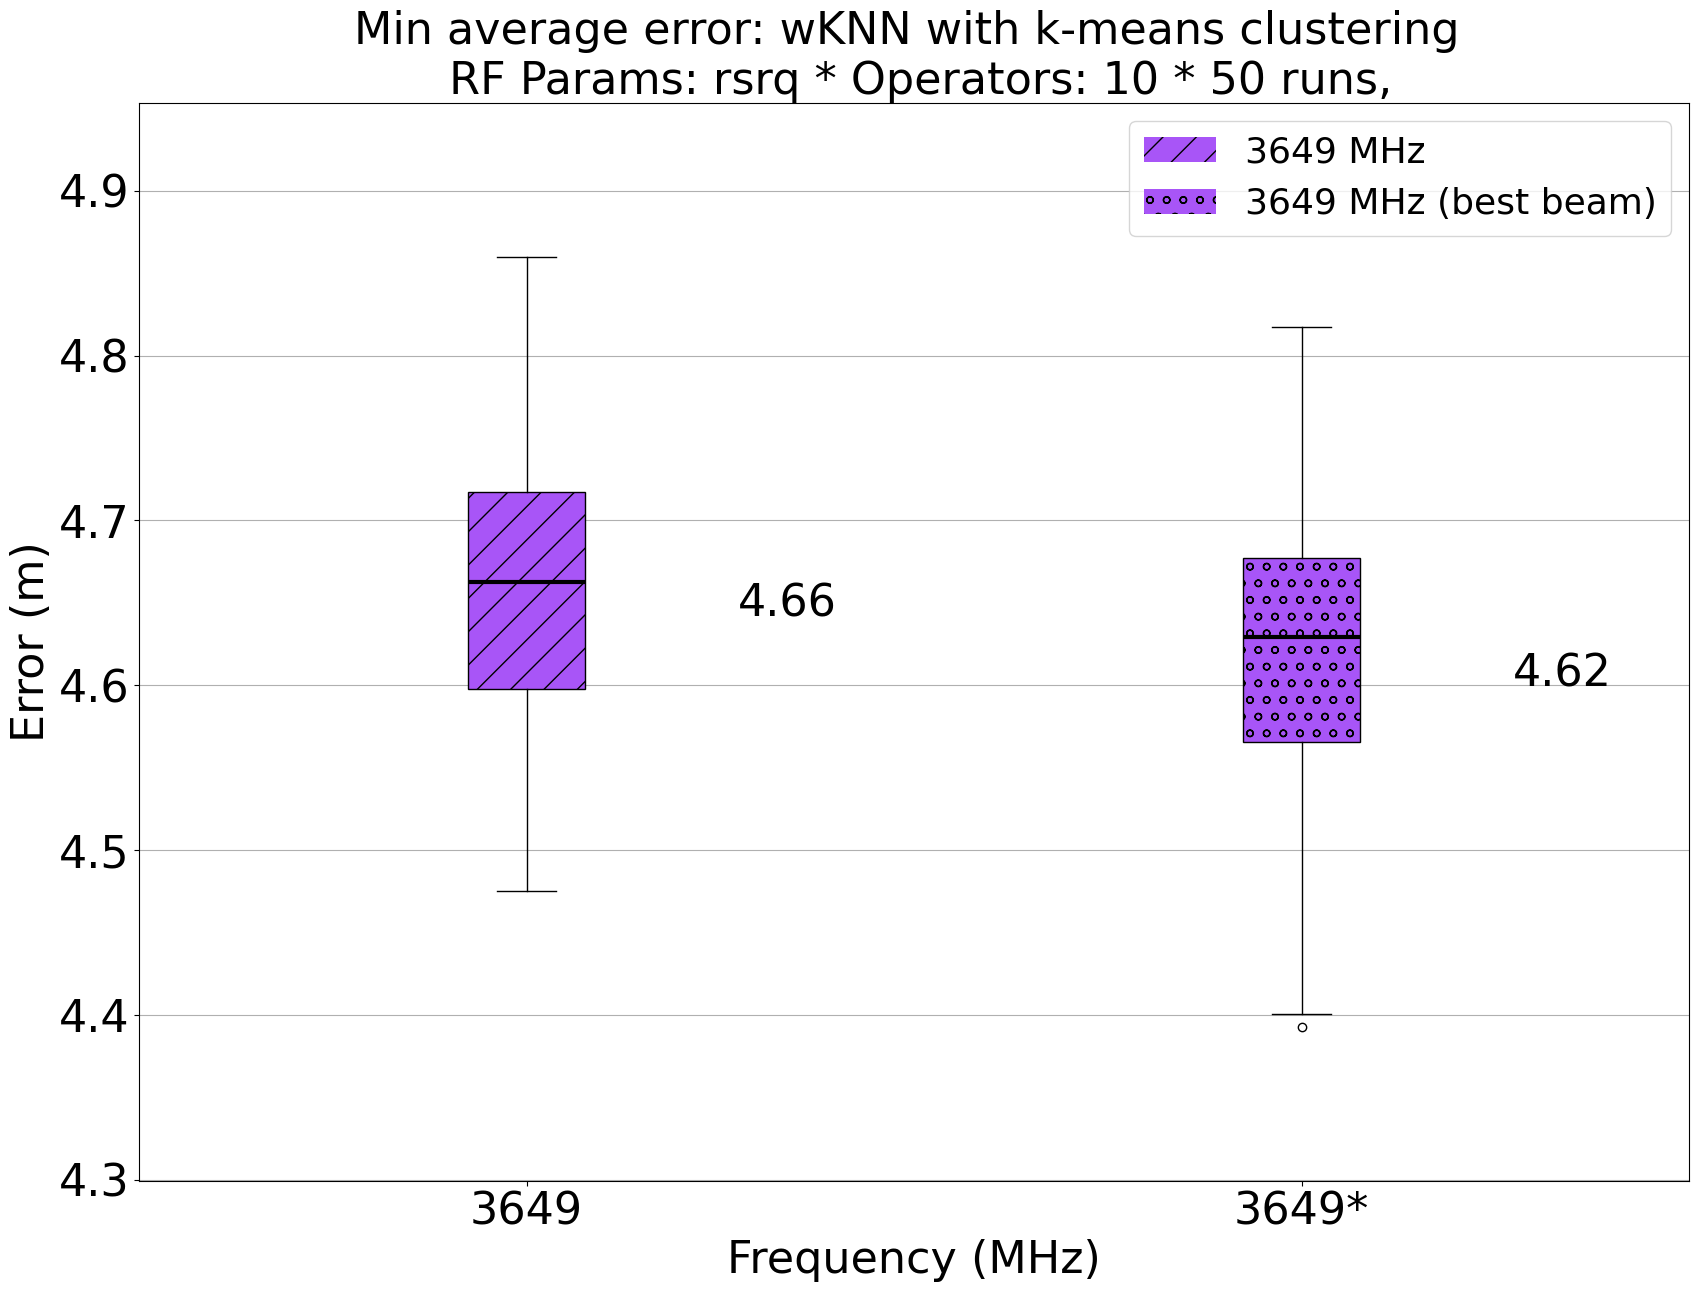

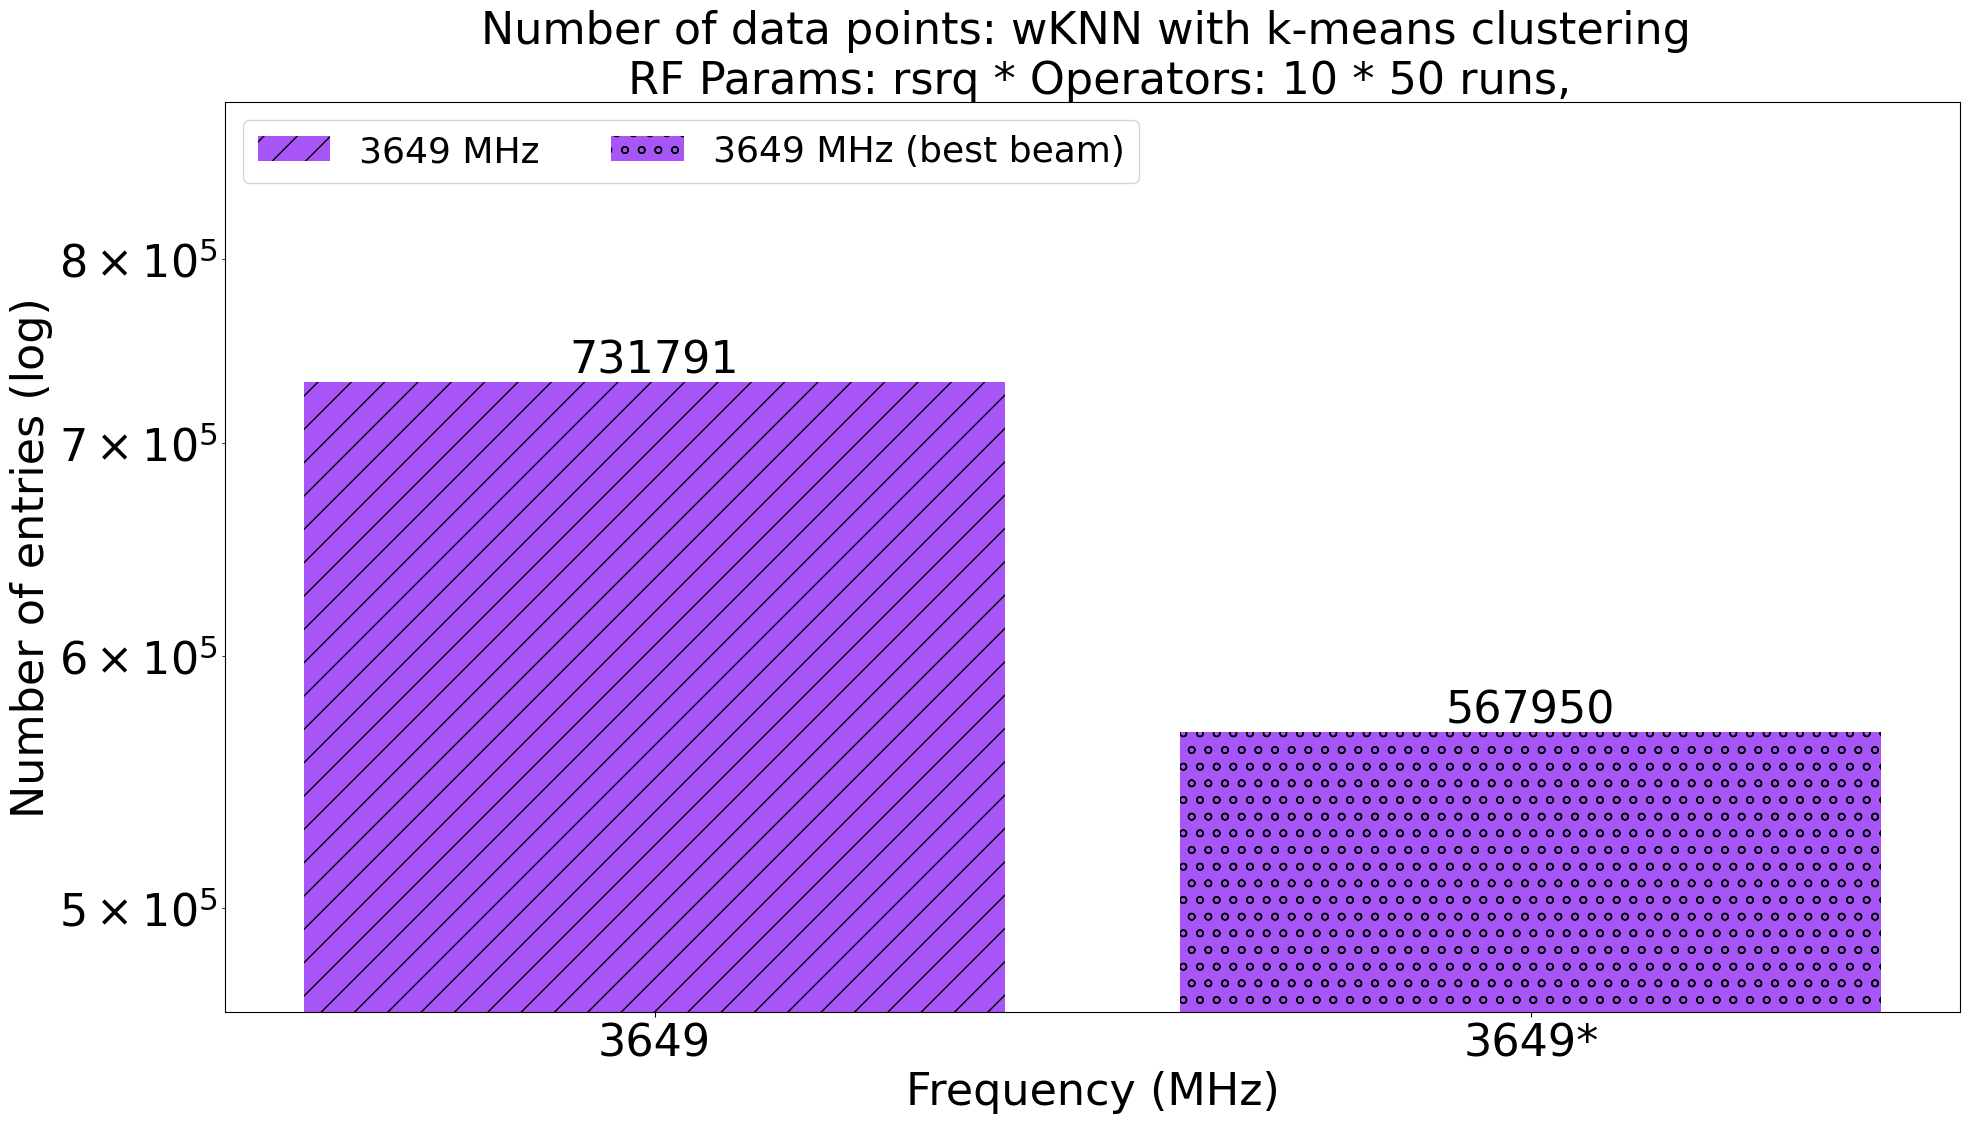

In [15]:
# all_cols = merge_alternate(order, star_order)
#
# print(all_cols)
#
display_cols = ['3649', '3649*', ]

all_errors = pd.concat([errors_df, errors_df_control], axis=1)[display_cols]
all_entries = pd.concat([entries_df, entries_df_control], axis=1)[display_cols]

make_boxplot(
    df=all_errors,
    title=f'Min average error: {title_string}',
    x_label='Frequency (MHz)',
    y_label='Error (m)',
    color=color_map,
    annotate=True,
)

make_barplot(
    df=all_entries,
    title=f'Number of data points: {title_string}',
    x_label='Frequency (MHz)',
    y_label='Number of entries (log)',
    color=color_map,
    annotate=True,
)